# Flow of a Stokes fluid in a lid-driven cavity

$$
\mathbb{S}
\begin{cases}
\Omega = [0, L_x] \times [0, L_y] \\
\textbf{u}_{\text{E}}(x,y=L_y)=u_{\text{lid}}\,\textbf{e}_x & \text{no-slip and no-penetration on entire boundary} \\
\textbf{u}_{\text{E}}(x,y=0)=\textbf{0} \\
\textbf{u}_{\text{E}}(x=0,y)=\textbf{0} \\
\textbf{u}_{\text{E}}(x=L_x,y)=\textbf{0} \\
p(x=0, y=0)=0 & \text{pressure constrained at a point to remove singularity}
\end{cases}
$$

In [1]:
import numpy as np
from ufl import grad
from lucifex.mesh import rectangle_mesh, mesh_boundary
from lucifex.fem import Function, Constant
from lucifex.solver import bvp, BoundaryConditions, OptionsPETSc
from lucifex.utils import get_component_fem_functions
from lucifex.viz import plot_colormap, plot_streamlines, save_figure

from lucifex.pde.stokes import stokes_incompressible


Lx = 1.0
Ly = 1.0
mesh = rectangle_mesh(Lx, Ly, 64, 64, 'quadrilateral')
boundary = mesh_boundary(
    mesh, 
    {
        "left": lambda x: x[0],
        "right": lambda x: x[0] - Lx,
        "lower": lambda x: x[1],
        "upper": lambda x: x[1] - Ly,
    },
)
mu = Constant(mesh, 1.0, 'mu')
stress = lambda u: mu * grad(u)

u_elem = ('P', 2, 2)
p_elem = ('P', 1)
u_p_elem = [u_elem, p_elem]
up = Function((mesh, u_p_elem), name="up")

u_lid = 1.0
bcs = BoundaryConditions(
    ('essential', boundary['upper'], (u_lid, 0.0), 0),
    ('essential', boundary['left', 'right', 'lower'], (0.0, 0.0), 0),
    ('essential', lambda x: np.isclose(x[0], 0.0) & np.isclose(x[1], 0.0), 0.0, 1),
    dofs_method='geometrical',
)

petsc = OptionsPETSc(pc_type='lu', pc_factor_mat_solver_type='mumps')
up_solver = bvp(stokes_incompressible, bcs, petsc)(up, stress)
up_solver.solve()

u, p = up.split(('u', 'p'), collapse=True)
ux, uy = get_component_fem_functions(('P', 1), u, names=('ux', 'uy'))

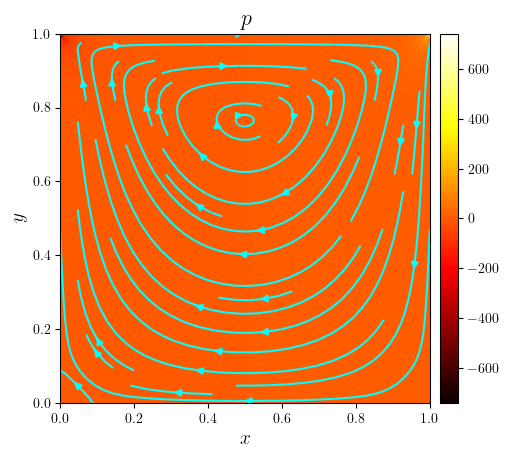

In [2]:
fig, ax = plot_colormap(p, title='$p$', x_label='$x$', y_label='$y$')
plot_streamlines(fig, ax, (ux, uy), density=0.75, color='cyan')
save_figure('streamlines')(fig)